# **Dense Embedding Playbooks and Sparse Retriever for Logs for Vector DB Storage**

In [51]:
# Importing pickle 
import pickle

#Importing Matplotlip

import matplotlib.pyplot as plt

In [44]:
# Loading the playbook chunks 
with open('../data/processed/playbook_chunks.pkl', 'rb') as f:
    playbook_chunks = pickle.load(f)

In [45]:
#Loading the Log_chunks 
with open('../data/processed/log_chunks.pkl', 'rb') as f:
    log_chunks = pickle.load(f)

Successfully loaded the `log_chunks` and `playbook_chunks`

In [46]:
#importing libraries
from langchain_huggingface import HuggingFaceEmbeddings

#Initializing the Sentence Transformer
embedding_model = HuggingFaceEmbeddings(
    model_name = 'sentence-transformers/all-MiniLM-L6-v2'
)
# Confriming the model has been staged
embedding_model

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 2860.88it/s]


HuggingFaceEmbeddings(model_name='sentence-transformers/all-MiniLM-L6-v2', cache_folder=None, model_kwargs={}, encode_kwargs={}, query_encode_kwargs={}, multi_process=False, show_progress=False)

Model loaded successfully.

In [31]:
# Providing one page content 
playbook_texts = [chunk.page_content for chunk in playbook_chunks]
print(f" Playbook text snippet: {playbook_texts[0]}")

 Playbook text snippet: Phase Identification: Triage alert, confirm IOC via EDR, snapshot affected host
Phase Containment: Isolate host from network, disable compromised user account
Phase Eradication: Remove malicious binaries, patch vulnerabilities
Phase Recovery: Restore from backups, monitor for reinfection
Phase Lessons Learned: Conduct IR debrief, update detection rules, user awareness training


In [32]:
#performing embedding on playbook
playbook_embeddings = embedding_model.embed_documents(playbook_texts)
print(f"playbook_text: {playbook_texts[0]}")
print(f" Embedding Length: {len(playbook_embeddings)}")
print(playbook_embeddings[:100])

playbook_text: Phase Identification: Triage alert, confirm IOC via EDR, snapshot affected host
Phase Containment: Isolate host from network, disable compromised user account
Phase Eradication: Remove malicious binaries, patch vulnerabilities
Phase Recovery: Restore from backups, monitor for reinfection
Phase Lessons Learned: Conduct IR debrief, update detection rules, user awareness training
 Embedding Length: 174
[[-0.06762837618589401, 0.00962178222835064, -0.0022535480093210936, -0.03102675825357437, 0.05112873762845993, -0.01248947624117136, 0.015158245339989662, -0.03502138704061508, -0.05447126924991608, 0.019514724612236023, 0.018146490678191185, -0.012894926592707634, 0.022165637463331223, -0.03685278445482254, 0.010832094587385654, -0.05929183214902878, -0.011762156151235104, -0.02704591490328312, 0.030485423281788826, -0.004733205772936344, -0.022522779181599617, 0.007962661795318127, -0.13061381876468658, 0.025127023458480835, -0.12719117105007172, 0.06147773563861847, 0.015

- Observation
Successfully embedded the `playbook_chunks` and got about 174 embeddings. 

# **Sparse Retriever BM25 for Logs**

In [ ]:
#reaffirming the log_chunks length
print(f"Length of Log_chunks: {len(log_chunks)}")

Length of Log_chunks: 11016


In [33]:
print(log_chunks[1:10])

[Document(metadata={'timestamp': '1721994830.9275465', 'src_ip': '', 'dst_ip': '', 'username': 'USER-1691', 'severity': '', 'label_binary': 'benign', 'src_port': '', 'dst_port': '', 'protocol': '', 'attack_tactics': '[]'}, page_content='Subject:\r\n\tSecurity ID:\t\tS-1-5-18\r\n\tAccount Name:\t\tIP-6440022A$\r\n\tAccount Domain:\t\tORG-0406\r\n\tORG-0063 ID:\t\t0x3AC37122\r\n\r\nORG-0063 Type:\t\t\t3\r\n\r\nThis event is generated when a ORG-0063 session is destroyed. It may be positively correlated with a ORG-0063 event using the ORG-0063 ID value. ORG-0063 IDs are only unique between reboots on the same computer.</Message><Level>Information</Level><Task>Logoff</Task><Opcode>Info</Opcode><Channel>Security</Channel><Provider>Microsoft ORG-0362 security auditing.</Provider><Keywords><Keyword>Audit Success</Keyword></Keywords></RenderingInfo></Event>'), Document(metadata={'timestamp': '1721994557.2679317', 'src_ip': '', 'dst_ip': '', 'username': '', 'severity': 'Info', 'label_binary': '

In [35]:
# viewing the log chunks
for i in range(min(3, len(log_chunks))):
    print(f"--- Log {i+1} ---")
    print(log_chunks[i].page_content[:300])  # First 300 characters
    print(f"Metadata: {log_chunks[i].metadata}")
    print("-" * 50)

--- Log 1 ---
<Event xmlns='http://schemas.microsoft.com/win/2004/08/events/event'><ORG-0111><Provider Name='Microsoft-ORG-0362-Security-Auditing' Guid='{54849625-5478-4994-a5ba-3e3b0328c30d}'/><EventID>4634</EventID><Version>0</Version><Level>0</Level><Task>12545</Task><Opcode>0</Opcode><Keywords>0x8020000000000
Metadata: {'timestamp': '1721994830.9275465', 'src_ip': '', 'dst_ip': '', 'username': 'USER-1691', 'severity': '', 'label_binary': 'benign', 'src_port': '', 'dst_port': '', 'protocol': '', 'attack_tactics': '[]'}
--------------------------------------------------
--- Log 2 ---
Subject:
	Security ID:		S-1-5-18
	Account Name:		IP-6440022A$
	Account Domain:		ORG-0406
	ORG-0063 ID:		0x3AC37122

ORG-0063 Type:			3

This event is generated when a ORG-0063 session is destroyed. It may be positively correlated with a ORG-0063 event using the ORG-0063 ID value. ORG-0063 ID
Metadata: {'timestamp': '1721994830.9275465', 'src_ip': '', 'dst_ip': '', 'username': 'USER-1691', 'severity': '',

###  Performing Tokenization for the Log_text using BM25

In [57]:
# importing bm25
from rank_bm25 import BM25Okapi

# preparing the log text
log_texts = [chunk.page_content for chunk in log_chunks]

# Tokeninzing using the simple split method to preserve IPs, Ports etc.
tokenized_logs = [text.lower().split() for text in log_texts]


In [40]:
# Show tokens for the first 3 log entries
for i in range(min(3, len(log_chunks))):
    text = log_chunks[i].page_content
    tokens = text.lower().split()
    print(f"Log {i+1} (first 20 tokens):")
    print(tokens[:20])  # Show first 20 tokens
    print()

Log 1 (first 20 tokens):
['<event', "xmlns='http://schemas.microsoft.com/win/2004/08/events/event'><org-0111><provider", "name='microsoft-org-0362-security-auditing'", "guid='{54849625-5478-4994-a5ba-3e3b0328c30d}'/><eventid>4634</eventid><version>0</version><level>0</level><task>12545</task><opcode>0</opcode><keywords>0x8020000000000000</keywords><timecreated", "org-0111time='2024-07-26t11:45:50.407036700z'/><eventrecordid>48381480</eventrecordid><correlation/><execution", "processid='656'", "threadid='5072'/><channel>security</channel><computer>user-0015-1171.example.internal</computer><security/></org-0111><eventdata><data", "name='targetusersid'>s-1-5-18</data><data", "name='targetusername'>ip-6440022a$</data><data", "name='targetdomainname'>org-0406</data><data", "name='targetorg-0063id'>0x3ac37122</data><data", "name='org-0063type'>3</data></eventdata><renderinginfo", "culture='en-us'><message>an", 'account', 'was', 'logged', 'off.', 'subject:', 'security', 'id:']

Log 2 (first 2

In [58]:
# Creating the BM25index
bm25 = BM25Okapi(tokenized_logs)

#Query 
query = "failed login"
tokenized_query = query.lower().split()
score = bm25.get_scores(tokenized_query)

#Get the top 5 results most relevant log entries for the query
top_n = bm25.get_top_n(tokenized_query, log_texts, n=5)

In [43]:
top_n

['<134>1 2024-07-26T06:53:18.228290-05:00 USER-0015-2651 eam-main - - - Caused by: USER-0015-0336.example.internal: Cannot complete login due to an incorrect user name or password.',
 '<134>1 2024-07-26T06:15:28.804905-05:00 USER-0015-2651 eam-main - - - Caused by: USER-0015-0336.example.internal: Cannot complete login due to an incorrect user name or password.',
 '<189>576666: LAVREP01: Jul 26 06:24:30.761 CDT: %SEC_LOGIN-5-LOGIN_SUCCESS: Login Success [user: sentinel] [Source: 10.46.83.161] [ORG-0414port: 22] at 06:24:30 CDT Fri Jul 26 2024',
 'USER-1555-WinLogBeat ::: {"@metadata":{"beat":"winlogbeat","type":"_doc","version":"8.2.2"},"@timestamp":"2024-07-26T11:16:38.334Z","USER-0015-0217":{"ephemeral_id":"47434381-3d10-4395-bc1c-5cdb52ecb35e","id":"12e13a9a-252a-493f-9c35-fa4d61abd0bc","name":"USER-0015-0040","type":"winlogbeat","version":"8.2.2"},"ecs":{"version":"8.0.0"},"event":{"action":"ORG-0111 Event","code":"521","created":"2024-07-26T11:16:39.061Z","kind":"event","outcome":

- Observation 

Successfully retrieved the top 5 revelant entries for the query `failed login` this means that when users ask such questions they can get relevant response. 

## Saving Embeddings and BM25 Tokenized Logs

In [ ]:
# importing numpy 
import numpy as np
import os

# Creating the directory to sve the files 
os.makedirs('../data/processed/embeddings_and_tokenized_logs', exist_ok=True)

# saving the playbook_embeddings as a numpy format since it is now numerical.
np.save('../data/processed/embeddings_and_tokenized_logs/playbook_embeddings.npy', playbook_embeddings)


In [55]:
# Saving the raw texts
with open('../data/processed/embeddings_and_tokenized_logs/log_texts.pkl', 'wb') as f:
    pickle.dump(log_texts, f)

## Saving the tokenized logs
with open('../data/processed/embeddings_and_tokenized_logs/tokenized_logs.pkl', 'wb') as f:
    pickle.dump(tokenized_logs, f)


# **Checking Cosine Similarity**

In [47]:
#Importing numpy needed for Cosine Similarity calculations
import numpy as np

In [48]:
#Loading the log_text.pkl file

with open('../data/processed/embeddings_and_tokenized_logs/log_texts.pkl', 'rb') as f:
    log_texts = pickle.load(f)

In [49]:
# Loading playbook chunks and their pre‑computed embeddings
with open('../data/processed/playbook_chunks.pkl', 'rb') as f:
    playbook_chunks = pickle.load(f)

# pre-computed embeddings 
playbook_embeddings = np.load('../data/processed/embeddings_and_tokenized_logs/playbook_embeddings.npy')

In [36]:
print(f"Length of embeddings: {len(playbook_embeddings)}")

Length of embeddings: 174


In [50]:
# Function to check Cosine Similarlity 
def search_playbooks(query: str, top_k: int = 5):
    """
    Search the playbook chunks using cosine similarity between the query and each pre‑computed chunk embedding.
    """
    # Embedding the query 
    query_emb = np.array(embedding_model.embed_query(query))
    
    # Normalizing the query embedding (making it unit length)
    query_norm = query_emb / np.linalg.norm(query_emb)
    
    # Normaliinge all playbook embeddings 
    playbook_norms = playbook_embeddings / np.linalg.norm(playbook_embeddings, axis=1, keepdims=True)
    
    #Computing cosine similarity = dot product of normalised vectors
    scores = np.dot(playbook_norms, query_norm)
    
    # Getting top_k indices
    top_indices = np.argsort(scores)[-top_k:][::-1]
    
    results = []
    for idx in top_indices:
        results.append({
            'score': scores[idx],
            'text': playbook_texts[idx],
            'metadata': playbook_chunks[idx].metadata
        })
    return results

## Testing the Similiarity Function

In [52]:
# First trial for query 1 
query_1 = "How do I contain a ransomware attack on a Windows server?"
results = search_playbooks(query, top_k=5)

for i, res in enumerate(results):
    print(f"Result {i+1} (Similarity: {res['score']:.4f}):")
    print(res['text'][:300])
    print(f"Metadata: {res['metadata']}")
    print("-" * 50)

Result 1 (Similarity: 0.4987):
Phase Identification: Analyze IDS logs, confirm fake portal
Phase Containment: Block malicious domains, reset credentials
Phase Eradication: Remove phishing site, update detection rules
Phase Recovery: Notify users, enforce MFA
Phase Lessons Learned: Conduct phishing training, update SSO security
Metadata: {'incident_id': 'IR-2025-0066', 'incident_type': 'Credential Harvesting', 'severity': 'High', 'final_status': 'Resolved'}
--------------------------------------------------
Result 2 (Similarity: 0.4987):
Phase Identification: Analyze IDS logs, confirm fake portal
Phase Containment: Block malicious domains, reset credentials
Phase Eradication: Remove phishing site, update detection rules
Phase Recovery: Notify users, enforce MFA
Phase Lessons Learned: Conduct phishing training, update SSO security
Metadata: {'incident_id': 'IR-2025-0169', 'incident_type': 'Credential Harvesting', 'severity': 'High', 'final_status': 'Resolved'}
---------------------------

- Observation 

As expected for `query_1`, similar chunks were returned with the similarity score that depicts how close the retrieved chunks are to the query processed. however, to avoid hallucination the incident_id metadata was also maintained adequately. 

In [53]:
# Second trial for the query 
query_2 = "How to handle a phishing attack"
results = search_playbooks(query, top_k=5)

for i, res in enumerate(results):
    print(f"Result {i+1} (Similarity: {res['score']:.4f}):")
    print(res['text'][:300])
    print(f"Metadata: {res['metadata']}")
    print("-" * 50)

Result 1 (Similarity: 0.4987):
Phase Identification: Analyze IDS logs, confirm fake portal
Phase Containment: Block malicious domains, reset credentials
Phase Eradication: Remove phishing site, update detection rules
Phase Recovery: Notify users, enforce MFA
Phase Lessons Learned: Conduct phishing training, update SSO security
Metadata: {'incident_id': 'IR-2025-0066', 'incident_type': 'Credential Harvesting', 'severity': 'High', 'final_status': 'Resolved'}
--------------------------------------------------
Result 2 (Similarity: 0.4987):
Phase Identification: Analyze IDS logs, confirm fake portal
Phase Containment: Block malicious domains, reset credentials
Phase Eradication: Remove phishing site, update detection rules
Phase Recovery: Notify users, enforce MFA
Phase Lessons Learned: Conduct phishing training, update SSO security
Metadata: {'incident_id': 'IR-2025-0169', 'incident_type': 'Credential Harvesting', 'severity': 'High', 'final_status': 'Resolved'}
---------------------------

- Observation 

For the sake of curiosity, a second query `query_2` was processed and similar chunks were returned, you can imagine for a question of how to handle phishing attack, returned chunks include `conducting phishing training and updating SSO security` 

In [54]:
# Run the playbook search first 
playbook_results = search_playbooks(query_1, top_k=10)

# Extract scores and labels
scores = [res['score'] for res in playbook_results]
labels = [f"Chunk {i+1}" for i in range(len(playbook_results))]

print(f"Scores retrieved from playbook_chunks: {len(scores)}")
print(f"Labels retrieved from playbook_chunks: {len(labels)}")

Scores retrieved from playbook_chunks: 10
Labels retrieved from playbook_chunks: 10


In [71]:
# Embedding the query 
query_emb = np.array(embedding_model.embed_query(query))

# Normalizing the query embedding (making it unit length)
query_norm = query_emb / np.linalg.norm(query_emb)
    
# Normaliinge all playbook embeddings 
playbook_norms = playbook_embeddings / np.linalg.norm(playbook_embeddings, axis=1, keepdims=True)

# Checking the scores distribution
all_scores = np.dot(playbook_norms, query_norm)
print(f"Min score: {all_scores.min():.4f}")
print(f"Max score: {all_scores.max():.4f}")
print(f"Mean score: {all_scores.mean():.4f}")
print(f"Std dev: {all_scores.std():.4f}")

Min score: 0.0116
Max score: 0.3099
Mean score: 0.1327
Std dev: 0.0612


In [72]:
specific_query = "How to isolate a Windows AD server during a ransomware incident"
specific_emb = np.array(embedding_model.embed_query(specific_query))
specific_norm = specific_emb / np.linalg.norm(specific_emb)
specific_scores = np.dot(playbook_norms, specific_norm)

print(f"Min: {specific_scores.min():.4f}")
print(f"Max: {specific_scores.max():.4f}")
print(f"Mean: {specific_scores.mean():.4f}")
print(f"Std:  {specific_scores.std():.4f}")

Min: 0.1144
Max: 0.5294
Mean: 0.2540
Std:  0.0753


## Visualization for Cosine Similarity 

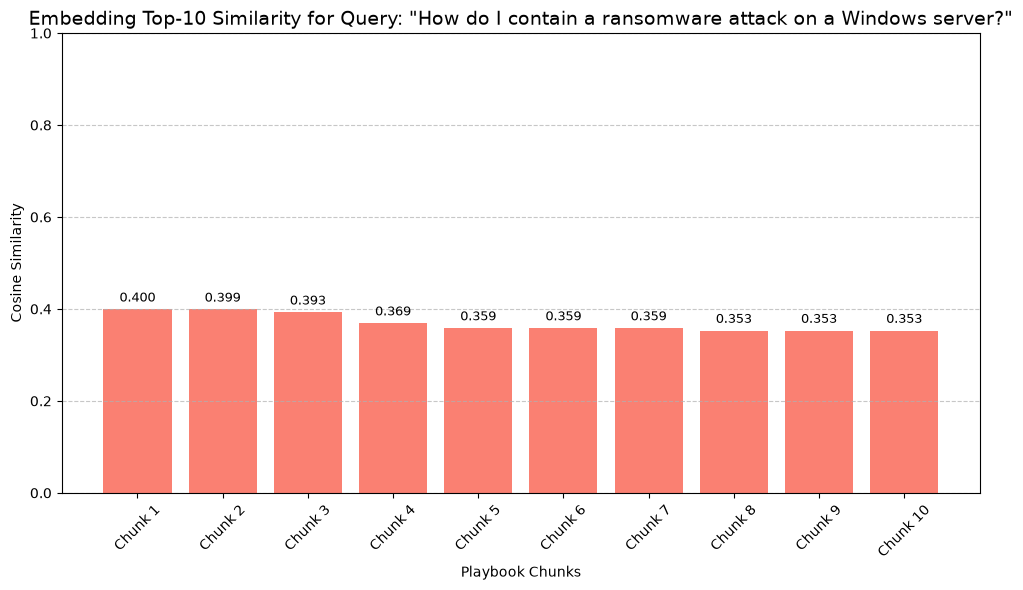

In [56]:
# Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, scores, color='salmon')
plt.title(f'Embedding Top-10 Similarity for Query: "{query_1}"', fontsize=14)
plt.xlabel('Playbook Chunks')
plt.ylabel('Cosine Similarity')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add score values on top of bars
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{score:.3f}', ha='center', va='bottom', fontsize=9)

plt.ylim(0, 1)  # Cosine similarity ranges from 0 to 1
plt.tight_layout()
plt.show()

- insight

Although the first trials were done using top-5 chunks, for the graph i selected top 10, and the similarity score ranges from 0.400 to 0.353. irrespective of the low figures we can see from the results that the returned chunks match the processed query. 

## BM25 Cosine Similarity Score

In [ ]:
#BM25_search function to normalize the query, and return the scores for each processed query
def bm25_search(query: str, top_k: int = 5):
    """Search the log corpus using BM25."""
    tokenized_query = query.lower().split()
    scores = bm25.get_scores(tokenized_query)
    top_indices = sorted(range(len(scores)), key=lambda i: scores[i], reverse=True)[:top_k]
    results = []
    for idx in top_indices:
        results.append({
            'score': scores[idx],
            'text': log_texts[idx],
            'index': idx
        })
    return results

In [66]:
# Running BM25 search first 
query_log = "10.184.211.180 failed authentication"
log_results = bm25_search(query_log, top_k=10)  # this will get top 10 for a nicer graph

# Extract scores and create labels (e.g., "Doc 1", "Doc 2")
scores = [res['score'] for res in log_results]
labels = [f"Doc {i+1}" for i in range(len(log_results))]

# Checking the len of what is retrieved 
print(f"Scores from BM25 retriever: {len(scores)}")
print(f"labels from BM25 retriever: {len(labels)}")

# Cheking the returned logs 
print(f"\n--- Top {len(log_results)} BM25 Results for: '{query_log}' ---\n")
for i, res in enumerate(log_results, start=1):
    print(f"Result {i} (Score: {res['score']:.4f}):")
    print(f"Text: {res['text'][:300]}...")  
    print("-" * 60)

Scores from BM25 retriever: 10
labels from BM25 retriever: 10

--- Top 10 BM25 Results for: '10.184.211.180 failed authentication' ---

Result 1 (Score: 8.7724):
Text: <134>1 2024-07-26T06:18:17.597799-05:00 USER-0015-2651 cis-license - - - 2024-07-26T06:18:17.597-05:00 vmomi-executor-1   INFO  USER-0015-0547.example.internal Validation failed for 60363: Authentication result: Saml token expired! (USER-0015-0928.example.internal)...
------------------------------------------------------------
Result 2 (Score: 6.7097):
Text: USER-1555-WinLogBeat ::: {"@metadata":{"beat":"winlogbeat","type":"_doc","version":"8.2.2"},"@timestamp":"2024-07-26T11:58:35.217Z","USER-0015-0217":{"ephemeral_id":"c7c916ce-56ef-4255-9f46-4ca9ce1b5050","id":"9c19b391-75f6-44e4-a324-d6fa6da22ca7","name":"USER-0015-0066","type":"winlogbeat","version...
------------------------------------------------------------
Result 3 (Score: 6.7097):
Text: USER-1555-WinLogBeat ::: {"@metadata":{"beat":"winlogbeat","type":"_doc",

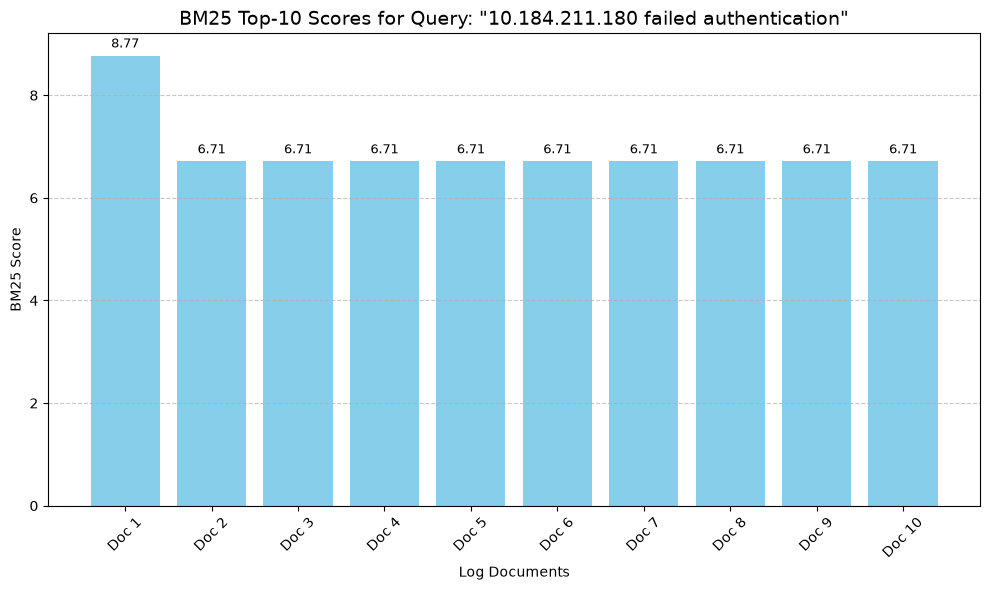

In [64]:
# Create the bar chart
plt.figure(figsize=(10, 6))
bars = plt.bar(labels, scores, color='skyblue')
plt.title(f'BM25 Top-10 Scores for Query: "{query_log}"', fontsize=14)
plt.xlabel('Log Documents')
plt.ylabel('BM25 Score')
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add score values on top of bars
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{score:.2f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

- Insight 
For the query on failed authentication, the BM25 retriever actually returned relevant chunks for about 10 documents. However, Doc1 seemed to have the highest relevance with a score of `8.77`